# Exercise 2: 2D Grid Cells

Aexc = Ainh = 1.0, σexc = 4.8, σinh = 5.0,.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import matplotlib.animation as animation
from IPython.display import HTML

## 2.1 2D Mexican hat

In [2]:
# Global parameters
M = 40
s0 = np.random.uniform(0,0.1, (4, M))
tau = 10e-3
B0 = 1
alpha = 0.1

In [3]:
A_exc = 1
A_inh = 1
sigma_exc = 4.8
sigma_inh = 5

def mexican_hat_2d(xv, yv, A_exc, sigma_exc, A_inh, sigma_inh):
    return A_exc*np.exp(-(xv**2+yv**2)/sigma_exc**2) - A_inh*np.exp(-(xv**2+yv**2)/sigma_inh**2)

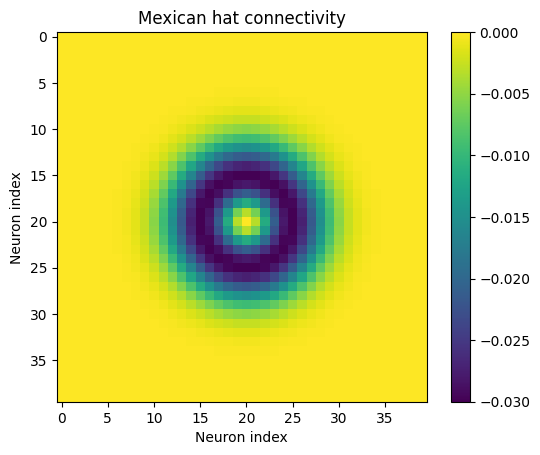

In [6]:
nx, ny = (M, M)
x = np.arange(-M/2, M/2, 1)
y = np.arange(-M/2, M/2, 1)
xv, yv = np.meshgrid(x, y)

w = mexican_hat_2d(xv, yv, A_exc, sigma_exc, A_inh, sigma_inh)
plt.imshow(w)
plt.title("Mexican hat connectivity")
plt.xlabel("Neuron index")
plt.ylabel("Neuron index")
plt.colorbar()
plt.show()

In [7]:
wE = np.zeros((M, M))
wW = np.zeros((M, M))
wN = np.zeros((M, M))
wS = np.zeros((M, M))
l = 1

wE[:, l:] = w[:, :-l]
wE[:, :l] = w[:, -l:]

wW[:, :-l] = w[:, l:]
wW[:, -l:] = w[:, :l]

wS[l:, :] = w[:-l, :]
wS[:l, :] = w[-l:, :]

wN[:-l, :] = w[l:, :]
wN[-l:, :] = w[:l, :]

wD = np.zeros((4, M, M))
wD[0] = wN
wD[1] = wS
wD[2] = wE
wD[3] = wW

## 2.2 Initial 2d solver with v = (0,0)

In [8]:
v_y = 0
v_x = 0

def ds_2D_1(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y),
    B0 * (1 - alpha*v_y),
    B0 * (1 + alpha*v_x),
    B0 * (1 - alpha*v_x),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='wrap')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds


In [9]:
def forward_euler(ds, tSpan, dt, s0, rec):

    t = np.arange(tSpan[0], tSpan[1]+dt/100, dt)
    s = np.zeros((4, M, M))
    s = s0
    tstamps = []
    
    for i in range(1, len(t)):

        s = s + dt * ds(s, t[i-1])

        if i % rec == 0:

            tstamps.append(np.sum(np.maximum(0, s), axis=0)) # Saving sums of firing rates at time stamps

    return np.array(tstamps)

In [10]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

history = forward_euler(ds_2D_1, tSpan=[0, 400e-3], dt=1e-3, s0=s0, rec=10)

In [11]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(history)):

    im = ax.imshow(history[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(history[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of grid formation")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

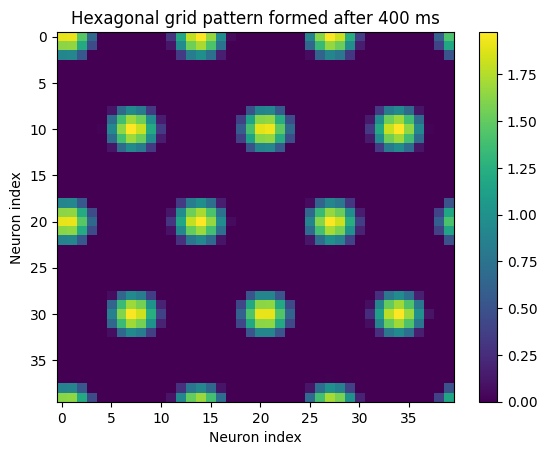

In [12]:
plt.imshow(history[-1], aspect='auto')
plt.title("Hexagonal grid pattern formed after 400 ms")
plt.xlabel("Neuron index")
plt.ylabel("Neuron index")
plt.colorbar()
plt.show()

## 2.3 Testing on different velocities

### Horizontal

In [13]:
v_y = 0
v_x = [0,1]

def ds_2D_H(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y),
    B0 * (1 - alpha*v_y),
    B0 * (1 + alpha*v_x[int(t//300e-3)]),
    B0 * (1 - alpha*v_x[int(t//300e-3)]),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='wrap')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds


In [14]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_Horizontal = forward_euler(ds_2D_H, [0, 600e-3], 1e-3, s0, 10)

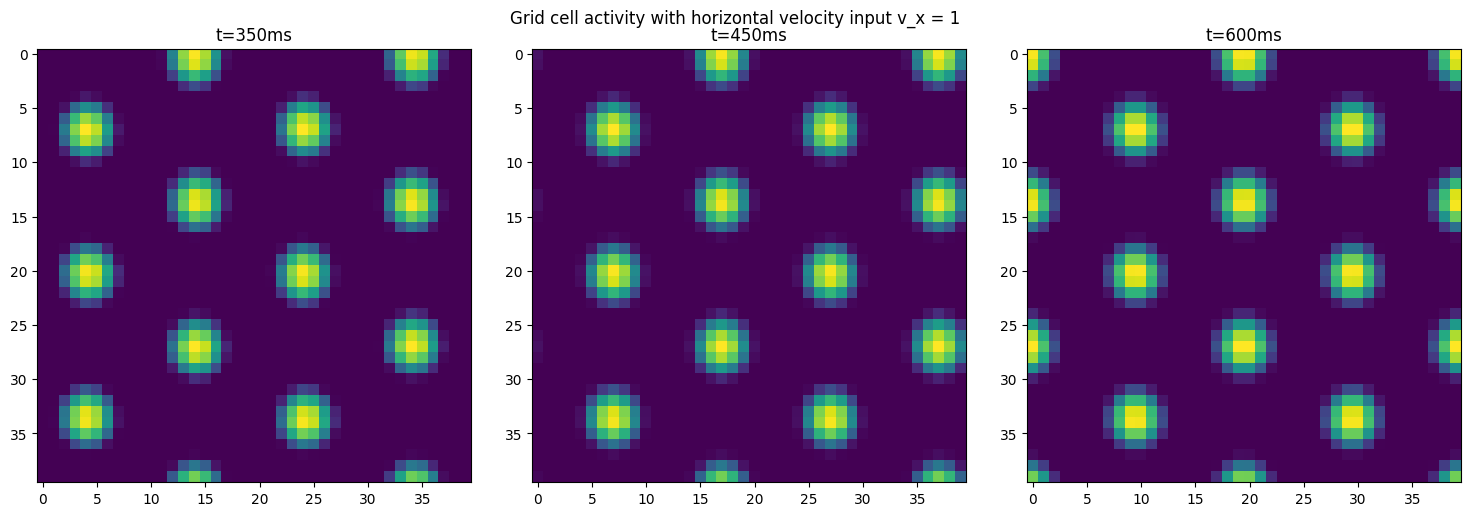

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sol_Horizontal[30])
axes[0].set_title('t=350ms')


axes[1].imshow(sol_Horizontal[45])
axes[1].set_title('t=450ms')


axes[2].imshow(sol_Horizontal[58])
axes[2].set_title('t=600ms')


plt.suptitle("Grid cell activity with horizontal velocity input v_x = 1")
plt.tight_layout()
plt.show()

In [95]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_Horizontal)):

    im = ax.imshow(sol_Horizontal[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_Horizontal[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of horizontal velocity v = [1, 0]")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

### Vertical

In [21]:
v_y = [0,1]
v_x = [0,0]

def ds_2D_V(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y[int(t//300e-3)]),
    B0 * (1 - alpha*v_y[int(t//300e-3)]),
    B0 * (1 + alpha*v_x[int(t//300e-3)]),
    B0 * (1 - alpha*v_x[int(t//300e-3)]),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='wrap')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds


In [22]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_Vertical = forward_euler(ds_2D_V, [0, 600e-3], 1e-3, s0, 10)

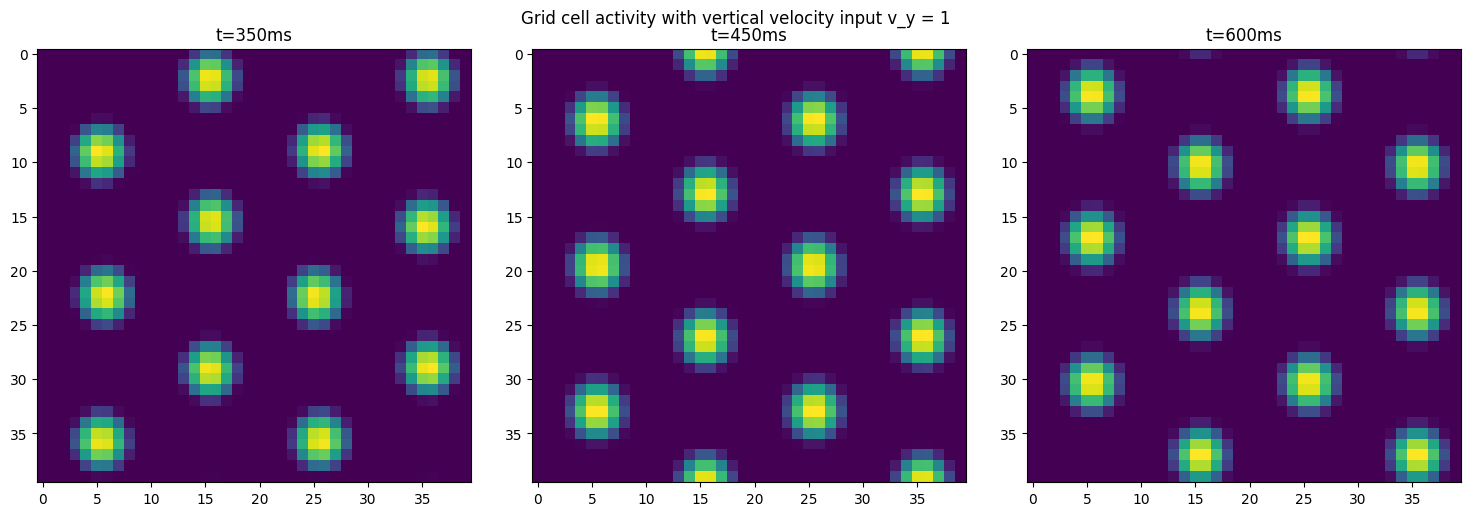

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sol_Vertical[30])
axes[0].set_title('t=350ms')

axes[1].imshow(sol_Vertical[45])
axes[1].set_title('t=450ms')

axes[2].imshow(sol_Vertical[58])
axes[2].set_title('t=600ms')
plt.suptitle("Grid cell activity with vertical velocity input v_y = 1")

plt.tight_layout()
plt.show()

In [99]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_Vertical)):

    im = ax.imshow(sol_Vertical[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_Vertical[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of vertical velocity v = [0, 1]")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

### Diagonal

In [25]:
v_y = [0,0.7]
v_x = [0,0.7]

def ds_2D_D(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y[int(t//300e-3)]),
    B0 * (1 - alpha*v_y[int(t//300e-3)]),
    B0 * (1 + alpha*v_x[int(t//300e-3)]),
    B0 * (1 - alpha*v_x[int(t//300e-3)]),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='wrap')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds


In [26]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_Diagonal = forward_euler(ds_2D_D, [0, 600e-3], 1e-3, s0, 10)

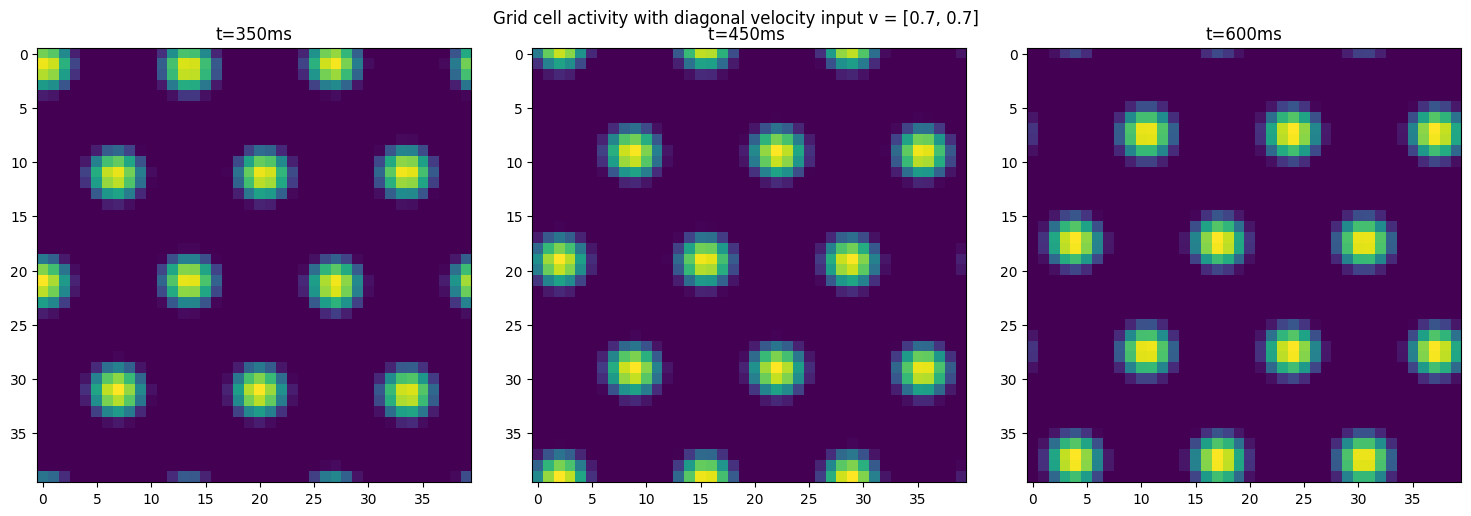

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sol_Diagonal[30])
axes[0].set_title('t=350ms')

axes[1].imshow(sol_Diagonal[45])
axes[1].set_title('t=450ms ')

axes[2].imshow(sol_Diagonal[58])
axes[2].set_title('t=600ms')

plt.suptitle("Grid cell activity with diagonal velocity input v = [0.7, 0.7]")

plt.tight_layout()
plt.show()

In [103]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_Diagonal)):

    im = ax.imshow(sol_Diagonal[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_Diagonal[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of diagonal velocity v = [0.7, 0.7]")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

## 2.4 Testing on random velocities (Bonus)

In [36]:
speeds = np.random.uniform(1,2, size=11)
speeds[0] = 0
thetas = np.random.uniform(0, 2*np.pi, size=11)
vs = np.zeros((11, 2))
for i in range(11):
    vs[i,0] = speeds[i]*np.cos(thetas[i])
    vs[i,1] = speeds[i]*np.sin(thetas[i])

In [37]:
v_y = vs[:,1]
v_x = vs[:,0]

def ds_2D_Rand(s, t):

    ds = np.zeros(s.shape)

    I_rec = 0
    r_vals = np.maximum(0, s)

    B = np.array([
    B0 * (1 + alpha*v_y[int(t//100e-3)]),
    B0 * (1 - alpha*v_y[int(t//100e-3)]),
    B0 * (1 + alpha*v_x[int(t//100e-3)]),
    B0 * (1 - alpha*v_x[int(t//100e-3)]),
    ]).reshape(4,1,1)

    for pop in range(len(s)):
        I_rec += scipy.ndimage.convolve(r_vals[pop], wD[pop], mode='wrap')

    for pop in range(len(s)):
        ds[pop] = 1/tau * ( -s[pop] + I_rec + B[pop])
    
    return ds


In [38]:
s0 = np.random.uniform(0, 0.1, (4, M, M))

sol_RandV = forward_euler(ds_2D_Rand, [0, 1100e-3], 1e-3, s0, 10)

In [33]:
fig, ax = plt.subplots()
# ims is a list of lists, each row is a list of artists to draw in the
# current frame; here we are just animating one artist, the image, in
# each frame
ims = []

for i in range(len(sol_RandV)):

    im = ax.imshow(sol_RandV[i], aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(sol_RandV[-1], aspect='auto')  # show an initial one first

    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True,
                                repeat_delay=1000)

plt.title("Animation of random velocities")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

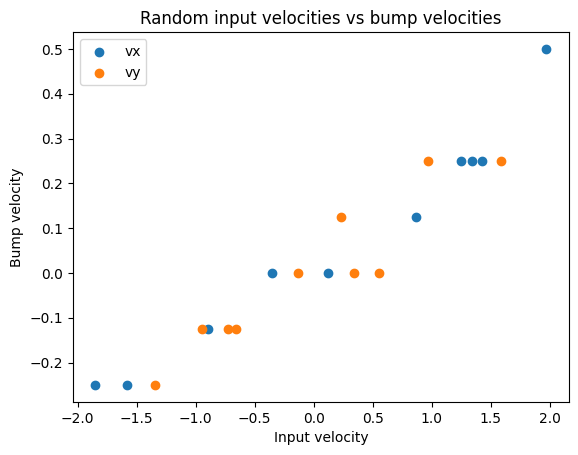

In [47]:

bVel_x = np.zeros(11)
bVel_y = np.zeros(11)


for i in range(0, 109, 10):

    k0 = np.array(np.unravel_index(np.argmax(sol_RandV[i, 10:30, 10:30], axis=None), sol_RandV[i, 10:30, 10:30].shape)) + [10, 10]
    ks = [k0]
    for j in range(1, 9):
        k0 = np.array(np.unravel_index(np.argmax(sol_RandV[i+j, k0[0]-5 : k0[0]+5, k0[1]-5 : k0[1]+5], axis=None), sol_RandV[i+j, k0[0]-5 : k0[0]+5, k0[1]-5 : k0[1]+5].shape))+ np.array([k0[0]-5, k0[1]-5])
        ks.append(k0) 
    
    
    ks = np.array(ks)

    bVel_x[i//10] = np.mean(ks[1:, 1]-ks[:-1, 1])
    bVel_y[i//10] = -np.mean(ks[1:, 0]-ks[:-1, 0])

plt.title('Random input velocities vs bump velocities')
plt.scatter(vs[1:, 0], bVel_x[1:], label='vx')
plt.scatter(vs[1:, 1], bVel_y[1:], label = 'vy')
plt.xlabel('Input velocity')
plt.ylabel('Bump velocity')
plt.legend()
plt.show()
